# Лабораторная работа №2
# "Cотрудничество клиента с банком"

ЦЕЛЬ РАБОТЫ - Спрогнозировать вероятность прекращения сотрудничества клиента с банком

РЕШАЕМАЯ ЗАДАЧА - Разработать и оценить классификатор, прогнозирующий вероятность прекращения сотрудничества клиента с банком

ХОД РАБОТЫ

1) Работа с данными:
    - 1.1 Загрузка данных
    - 1.2 Предобработка данных
    - 1.3 Исследовательский анализ данных
    - 1.4 Корреляционный анализ
2) Обучение эталонных моделей:
    - 2.1 Разбиение исходных данных на обучающий и контрольный наборы
    - 2.2 Обучение базововой модели без учета дисбаланса
    - 2.3 Рассчет базовых метрик качества
3) Оптимизация с учетом дисбаланса
    - 3.1 Решение проблемы дисбаланса классов
    - 3.2 Обучение нескольких алгоритмов
    - 3.3 Поиск лучшей модели
4) Итоговое тестирование и сравнение
    - 4.1 Оценка финальной модели
    - 4.2 Сравнение F1-меры с ROC AUC, взаимосвязь и практичсекая значимость
    - 4.3 Рекомендации по использованию модели в бизнес-процессах
5) Итоговые выводы

ОПИСАНИЕ ДАННЫХ

Данные таблицы Bank_data.csv содержат следующую информацию:

- Number — индекс строки в данных
- CustomerId — уникальный идентификатор клиента
- Surname — фамилия
- CreditScore — кредитный рейтинг
- Geography — страна проживания
- Gender — пол
- Age — возраст
- Tenure — сколько лет человек является клиентом банка
- Balance — баланс на счёте
- NumOfProducts — количество продуктов банка, используемых клиентом
- HasCrCard — наличие кредитной карты
- IsActiveMember — активность клиента
- EstimatedSalary — предполагаемая зарплата
- Exited — факт ухода клиента

<div class="alert-danger"> 
<b>ОСНОВНОЕ ТРЕБОВАНИЕ — добиться F1-меры не ниже 0.59 на тестовом наборе. Для дополнительного анализа качества использовать метрику ROC AUC</b> 

# Импорт необходимых пакетов

In [1]:
# pip install imbalanced-learn 

In [2]:
# pip install xgboost lightgbm catboost

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import phik

from phik import phik_matrix
from phik.report import plot_correlation_matrix
from plotly.subplots import make_subplots

from scipy import stats as st
from scipy.stats import binom, poisson
from scipy.stats import gaussian_kde
from scipy.spatial.distance import cosine
from scipy.spatial.distance import euclidean

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, make_scorer
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve

from sklearn.datasets import  make_classification
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
import warnings
import joblib

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 50
TEST_SIZE = 0.25

## Шаг 1. Работа с данными

### 1.1 Загрузка данных

In [4]:
data = pd.read_csv('Bank_data.csv')

<div class="alert-success"> 
<b> </b>
    
Функция для начальной проверки данных, чтобы увидеть что данные выгрузились без ошибок) </div>

In [5]:
def check_data(DATA):
    print('Первые 5 строк **************************************************************************************************************************')
    display(DATA.head())
    print('Последние 5 строк *************************************************************************************************************************')
    display(DATA.tail())
    print('Название столбцов *************************************************************************************************************************')
    print(DATA.columns)
    print('Общая информация  ***************************************************************************************************************')
    print(DATA.info())
    print('Число ЯВНЫХ дубликатов ********************************************************************************************************************')
    print(DATA.duplicated().sum())
    print('Число пропусков у каждого признака ********************************************************************************************************************')
    print(DATA.isna().sum())
    display(DATA.describe().T)
    DATA.hist(figsize=(15, 20))

Первые 5 строк **************************************************************************************************************************


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


Последние 5 строк *************************************************************************************************************************


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5.0,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10.0,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7.0,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3.0,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,NaN,130142.79,1,1,0,38190.78,0


Название столбцов *************************************************************************************************************************
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
Общая информация  ***************************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 n

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,9091.0,4.997690e+00,2.894723,0.00,2.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


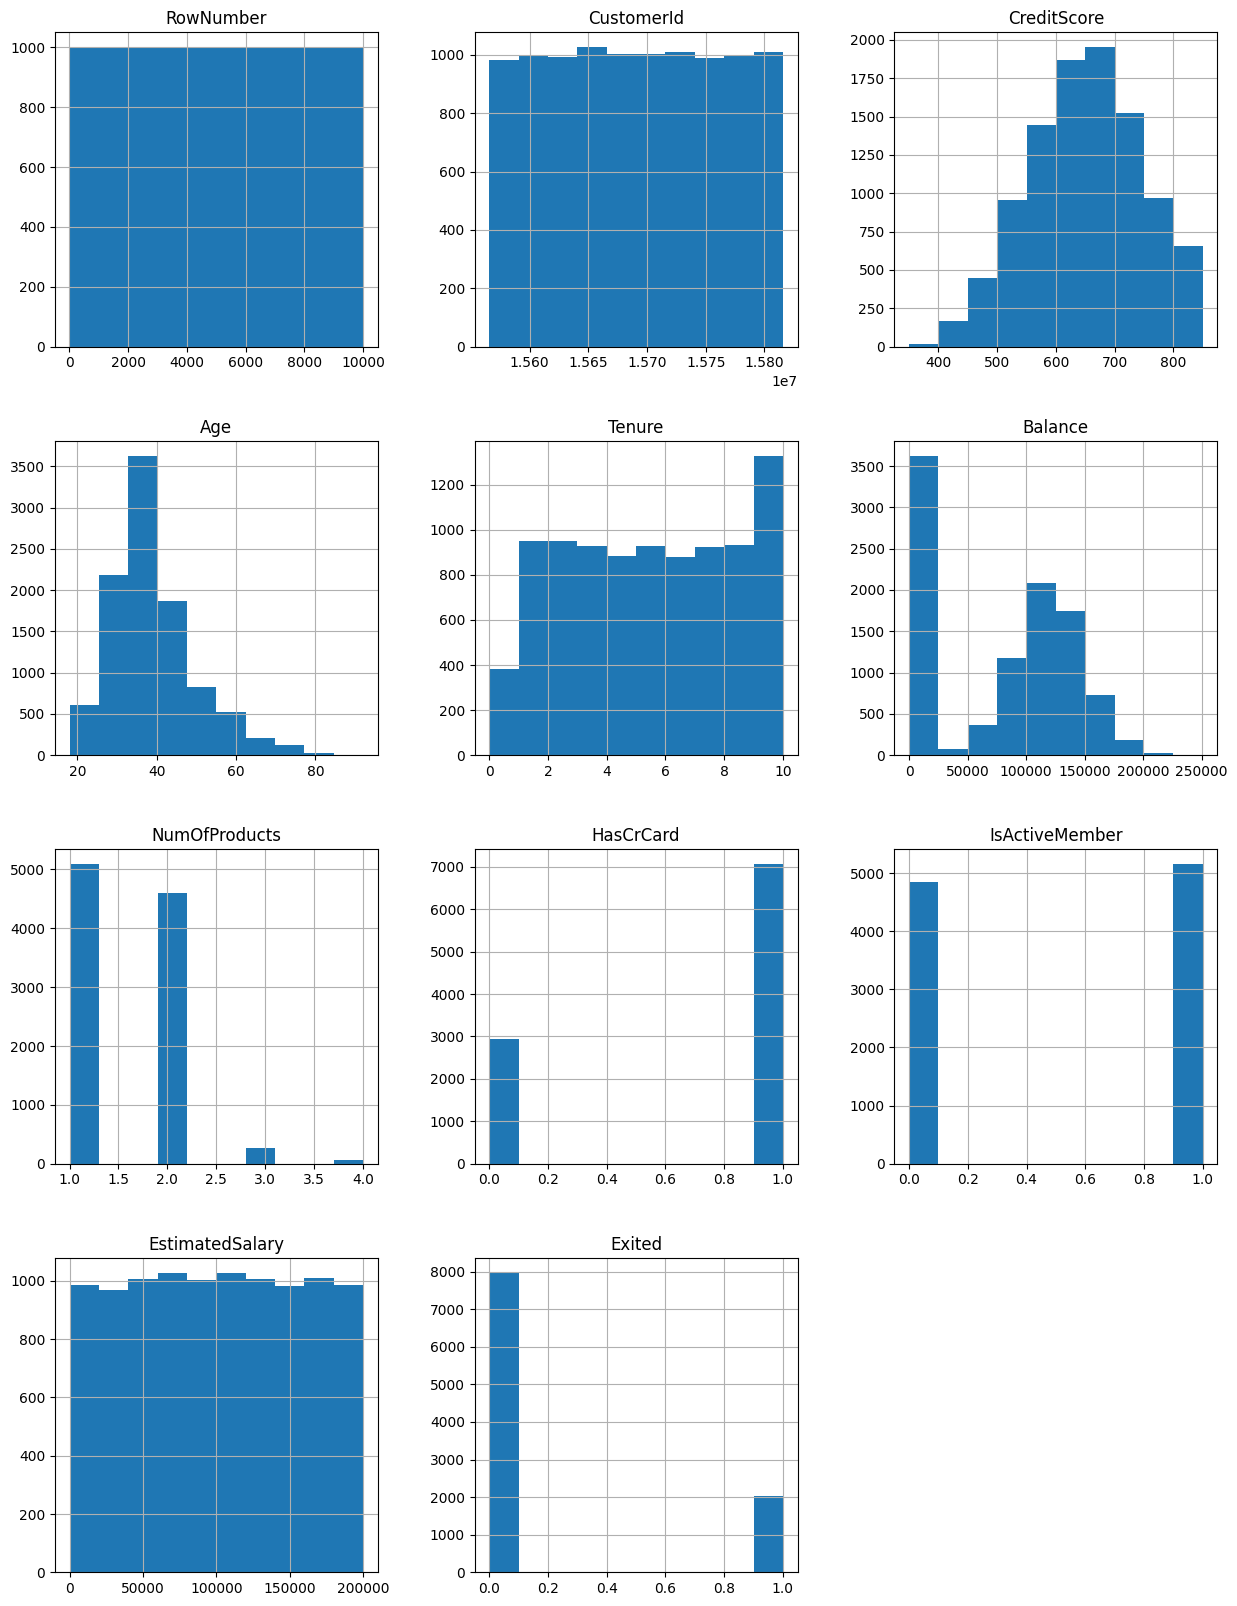

In [6]:
check_data(data)

<div class="alert-success"> 
<b> </b>
    
- Ну что же, первое что бросается в глаза это название столбцов, они не по-феншую, по правилу хорошего стиля они должны быть все с маленькой буквы и через нижнее подчеркивание.
- Второе - в данных почти нет пропусков, пропуски есть только в одном признаке - "Tenure".
- Третье - явных дубликатов в данных не обнаружено
- В - четвертых, по построенным гистограммам невооруженным глазом видно наличие ДИСБАЛАНСА КЛАССОВ в целевом признаке - Exidet
- Пятое - Типы данных -  в столбце Tenure можно поменять тип на int, так как количсетво лет - целое число)


А вообще данные довольно "чистые", если так можно выразится))) Можно переходить к следующему шагу данного этапа
</div>

### 1.2 Предобработка данных

<div class="alert-success"> 
<b> </b>
    
Для начала переименуем столбцы по правилу хорошего стиля, далее поищем неявные дубликаты и если что избавимся от них, после поменяем тип данных в столбце Tenure, а что касается пропусков в данном признаке - просто заменим на 0, скорее всего пропуск значит, что просто клиент только пришел в банк)
</div>

In [7]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [8]:
data = data.rename(
    columns={
        'RowNumber': 'row_number', 
        'CustomerId': 'customer_id', 
        'Surname': 'surname', 
        'CreditScore': 'credit_score',
        'Geography': 'geography',
        'Gender': 'gender', 
        'Age': 'age',
        'Tenure': 'tenure', 
        'Balance': 'balance', 
        'NumOfProducts': 'num_of_products', 
        'HasCrCard': 'has_cr_card',
        'IsActiveMember': 'is_active_member',
        'EstimatedSalary': 'estimated_salary',
        'Exited': 'exited'
        
    }
)

In [9]:
data.columns

Index(['row_number', 'customer_id', 'surname', 'credit_score', 'geography',
       'gender', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card',
       'is_active_member', 'estimated_salary', 'exited'],
      dtype='object')

In [10]:
columns = ['surname', 'geography', 'gender']
for column in columns:
    print(f'Вывод всех уникальных значений признака {column}')
#    np.set_printoptions(threshold=np.inf) # чтобы полностью весь список вывести добавила
    print(data[column].unique())

Вывод всех уникальных значений признака surname
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
Вывод всех уникальных значений признака geography
['France' 'Spain' 'Germany']
Вывод всех уникальных значений признака gender
['Female' 'Male']


<div class="alert-success"> 
<b> </b>
    
Ну что же, в столбцах geography и gender неявных дубликатов необнаружено, однако точно нельзя сказать о столбце surname, потому что, с одной стороны там есть такие на первый взгляд неявные дубликаты как 'Hargrave' и 'Hargraves' или 'MacDonald' и 'McDonald', или O'Donnell и ODonnell, НО ТОЧНО НЕЛЬЗЯ УТВЕРЖДАТЬ ЧТО ЭТО РАЗНЫЕ ИНТЕРПРИТАЦИИ ОДНОЙ ФАМИЛИИ ОДНОГО ЧЕЛОВЕКА, ПОТОМУ ЧТО ФАМИЛЛИИ МОГУТ БЫТЬ СОЗВУЧНЫ И ПИСАТЬСЯ ПОЧТИ ОДИНАКОГО НО ПРИНАДЛЕЖАТЬ РАЗНЫМ ЛЮДЯМ, поэтому будем считать что в этом столбце нет неявных дубликатов и оставим как есть)
</div>

In [11]:
print('Процент пропусков в признаке tenure: ')
print((data['tenure'].isna().sum() / len(data)) * 100)

Процент пропусков в признаке tenure: 
9.09


In [12]:
data['tenure'] = data['tenure'].fillna(0)

In [13]:
data.isna().sum()

row_number          0
customer_id         0
surname             0
credit_score        0
geography           0
gender              0
age                 0
tenure              0
balance             0
num_of_products     0
has_cr_card         0
is_active_member    0
estimated_salary    0
exited              0
dtype: int64

In [14]:
data['tenure'] = data['tenure'].astype('int64')

In [15]:
data.dtypes

row_number            int64
customer_id           int64
surname              object
credit_score          int64
geography            object
gender               object
age                   int64
tenure                int64
balance             float64
num_of_products       int64
has_cr_card           int64
is_active_member      int64
estimated_salary    float64
exited                int64
dtype: object

<div class="alert-success"> 
<b> </b>
Итак, на данном этапе были изменены названия столбцов, удалены пропуски и датасет был проверен на наличие неявных дубликатов (не обнаружено), приведен тип данных столбца tenure в int64
</div>

### 1.3 Исследовательский анализ данных

<div class="alert-success"> 
<b> </b>
Посмотрим как распределены признаки в датасете, постром гистограммы, ящик с усами и круговую диаграмму)
</div>

In [16]:
def hist(column):
    print(data[column].describe())
    plt.hist(data[column])
    plt.title(f'Гистограмма распределения признака {column}')
    plt.xlabel(column)
    plt.ylabel("Количество клиентов")
    plt.show()
def bxplt(column):
    sns.boxplot(data=data, y=column)
    plt.title("Диаграмма размаха")
    plt.ylabel(column)
def pie(column):
    counts = data[column].value_counts()
    print(counts)
    fig, ax = plt.subplots()
    ax.pie(counts, labels=counts.index, autopct='%.2f%%')
    plt.title(f"Распределение признака {column}")
    plt.show()

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_number        10000 non-null  int64  
 1   customer_id       10000 non-null  int64  
 2   surname           10000 non-null  object 
 3   credit_score      10000 non-null  int64  
 4   geography         10000 non-null  object 
 5   gender            10000 non-null  object 
 6   age               10000 non-null  int64  
 7   tenure            10000 non-null  int64  
 8   balance           10000 non-null  float64
 9   num_of_products   10000 non-null  int64  
 10  has_cr_card       10000 non-null  int64  
 11  is_active_member  10000 non-null  int64  
 12  estimated_salary  10000 non-null  float64
 13  exited            10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


<div class="alert-warning"> 
<b> </b>
Признак credit_score — кредитный рейтинг
</div>

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: credit_score, dtype: float64


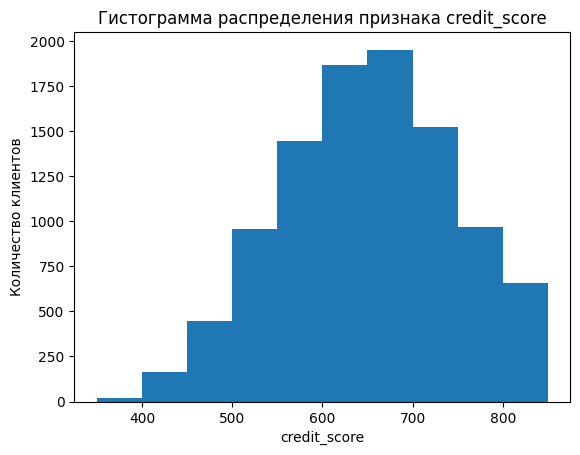

In [18]:
hist('credit_score')

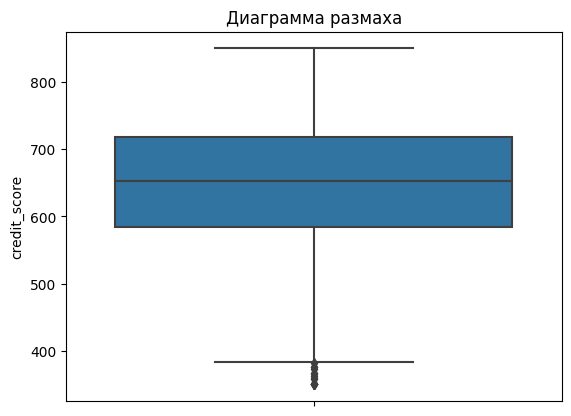

In [19]:
bxplt('credit_score')

In [20]:
print(f'Процент выбросов в признаке "credit_score": {(len(data.query("credit_score < 400")) / len(data) * 100)}%')

Процент выбросов в признаке "credit_score": 0.19%


<div class="alert-success"> 
<b> </b>
Маленький процент, оставляем как есть, все равно ничего не изменит сильно
</div>

<div class="alert-warning"> 
<b> </b>
Признак geography — страна проживания
</div>

France     5014
Germany    2509
Spain      2477
Name: geography, dtype: int64


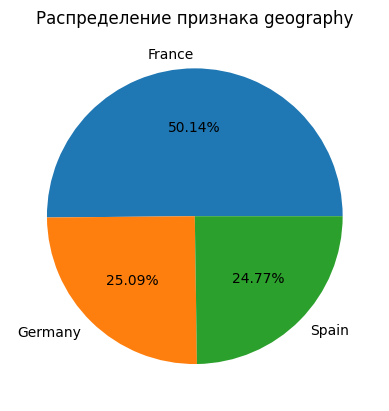

In [21]:
pie('geography')

<div class="alert-success"> 
<b> </b>
Стоит отметить что чуть больше половины клиентов в базе - из Франции, эта информация поможет при составлении рекомендаций банку для уменьшения оттока клиента)
</div>

<div class="alert-warning"> 
<b> </b>
Признак gender — пол
</div>

Male      5457
Female    4543
Name: gender, dtype: int64


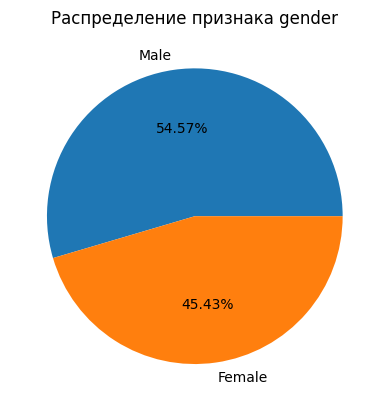

In [22]:
pie('gender')

<div class="alert-success"> 
<b> </b>
Среди клиентов банка большинство - парней, это тоже стоит учесть при составлении рекомендаций)
</div>

<div class="alert-warning"> 
<b> </b>
Признак age — возраст
</div>

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: age, dtype: float64


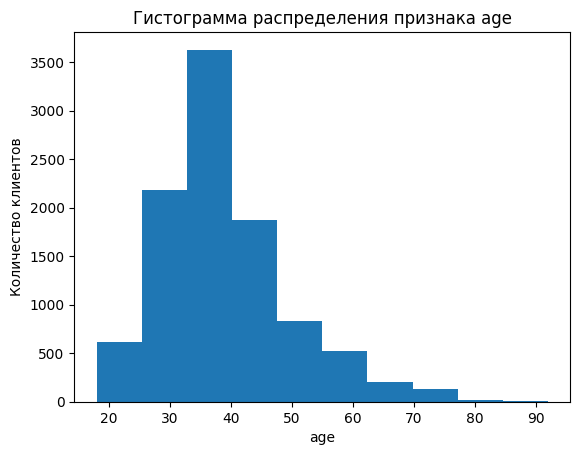

In [23]:
hist('age')

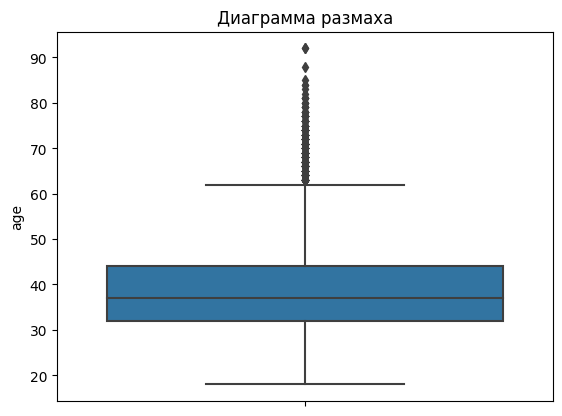

In [24]:
bxplt('age')

In [25]:
print(f'Процент выбросов в признаке "age": {(len(data.query("age > 61")) / len(data) * 100)}%')

Процент выбросов в признаке "age": 4.109999999999999%


In [26]:
data = data.query("age <= 61")

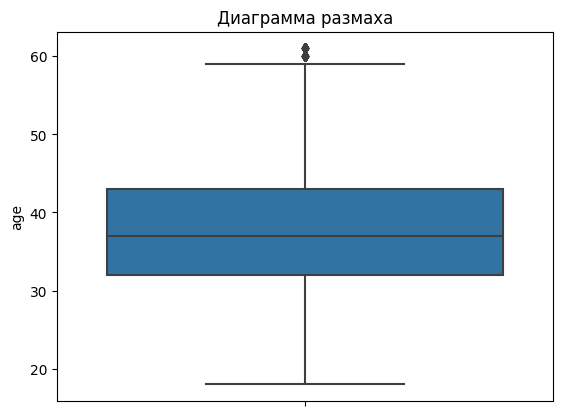

In [27]:
bxplt('age')

<div class="alert-success"> 
<b> </b>
Удаляем клиентов старше 61, так как это выбросы и их процент в признаке состовляет 4.1%
</div>

<div class="alert-warning"> 
<b> </b>
Признак tenure — сколько лет человек является клиентом банка
</div>

count    9589.000000
mean        4.539577
std         3.109466
min         0.000000
25%         2.000000
50%         4.000000
75%         7.000000
max        10.000000
Name: tenure, dtype: float64


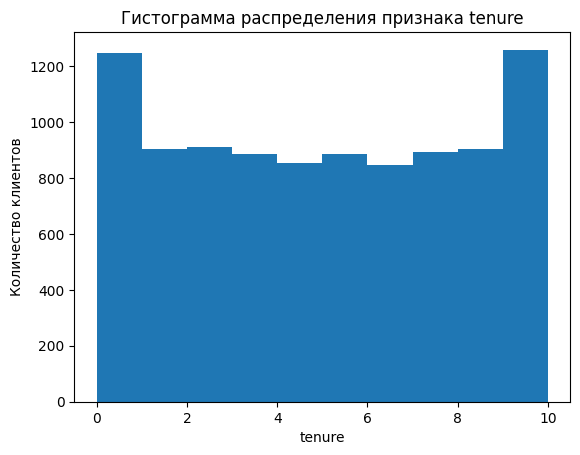

In [28]:
hist('tenure')

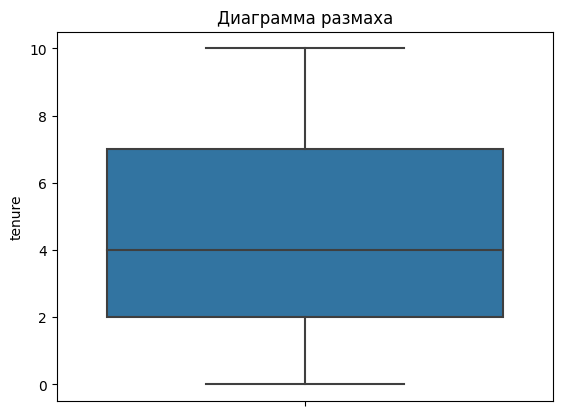

In [29]:
bxplt('tenure')

<div class="alert-success"> 
<b> </b>
Выбросов нет, однако отметим, что более 1200 клиентов уже примерно 10 лет с банком)
</div>

<div class="alert-warning"> 
<b> </b>
Признак balance — баланс на счёте

</div>

count      9589.000000
mean      76552.236761
std       62422.133272
min           0.000000
25%           0.000000
50%       97266.100000
75%      127661.690000
max      250898.090000
Name: balance, dtype: float64


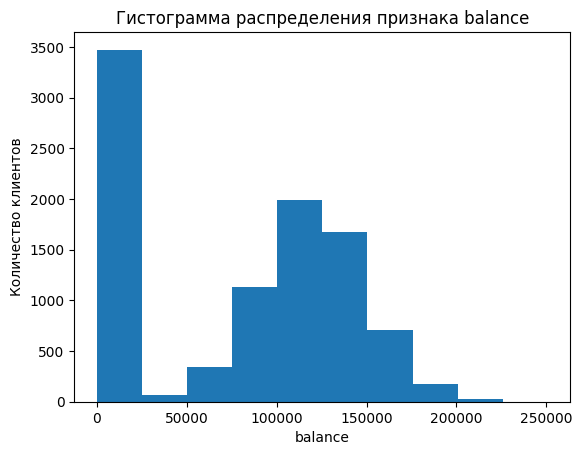

In [30]:
hist('balance')

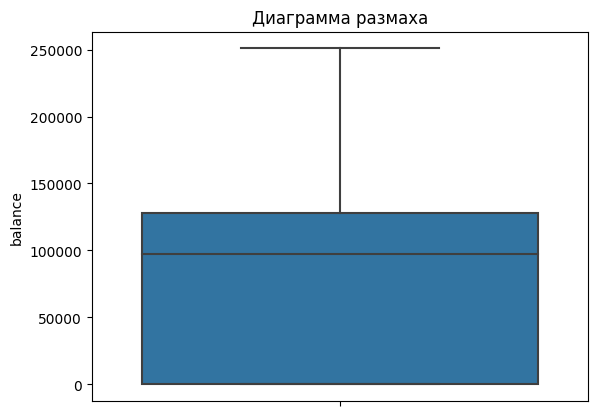

In [31]:
bxplt('balance')

<div class="alert-success"> 
<b> </b>
Очень странное распределение признаков, однако выбросов не наблюдается)
</div>

<div class="alert-warning"> 
<b> </b>
Признак num_of_products — количество продуктов банка, используемых клиентом

</div>

count    9589.000000
mean        1.530921
std         0.581498
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         4.000000
Name: num_of_products, dtype: float64


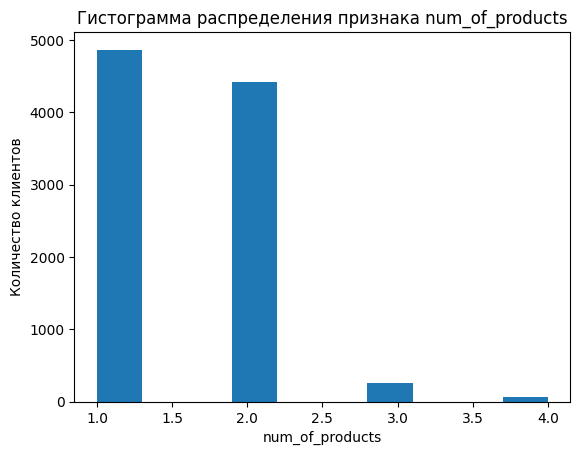

In [32]:
hist('num_of_products')

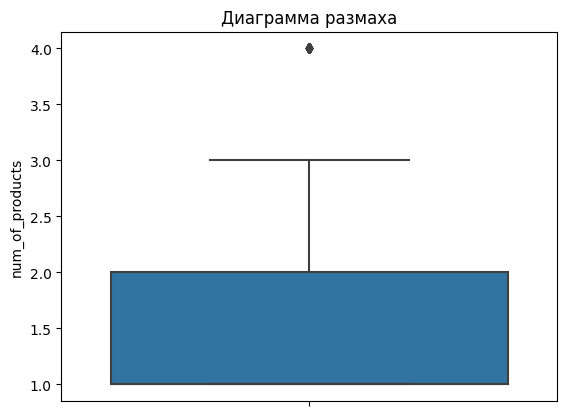

In [33]:
bxplt('num_of_products')

In [34]:
print(f'Процент выбросов в признаке "num_of_products": {(len(data.query("num_of_products > 3")) / len(data) * 100)}%')

Процент выбросов в признаке "num_of_products": 0.615288351235791%


<div class="alert-success"> 
<b> </b>
А мне пофиг, потому что процент маленький) не трогаем оставляем как есть 
</div>

<div class="alert-warning"> 
<b> </b>
Признак has_cr_card — наличие кредитной карты

</div>

1    6768
0    2821
Name: has_cr_card, dtype: int64


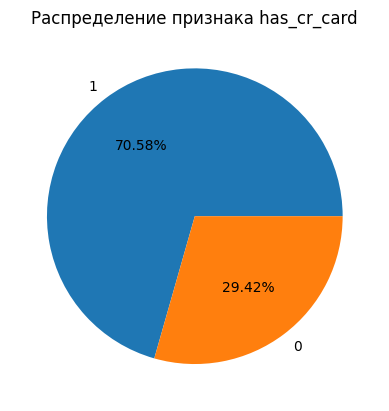

In [35]:
pie('has_cr_card')

<div class="alert-success"> 
<b> </b>
У большинства клиентов банка - есть кредитная карта)
</div>

<div class="alert-warning"> 
<b> </b>
Признак is_active_member — активность клиента

</div>

1    4815
0    4774
Name: is_active_member, dtype: int64


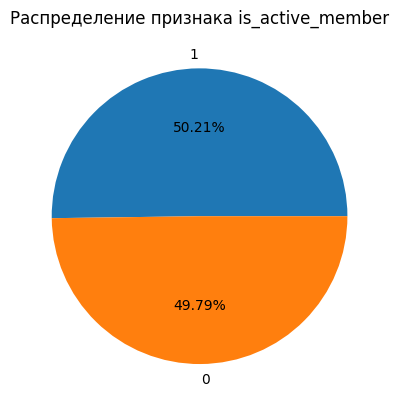

In [36]:
pie('is_active_member')

<div class="alert-success"> 
<b> </b>
Активных клиентов почти столько же сколько неактивных)
</div>

<div class="alert-warning"> 
<b> </b>
Признак estimated_salary — предполагаемая зарплата

</div>

count      9589.000000
mean     100200.278401
std       57500.956105
min          11.580000
25%       51226.320000
50%      100335.550000
75%      149458.730000
max      199992.480000
Name: estimated_salary, dtype: float64


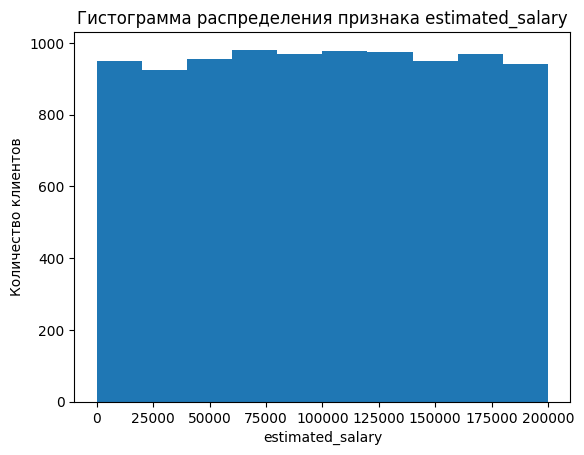

In [37]:
hist('estimated_salary')

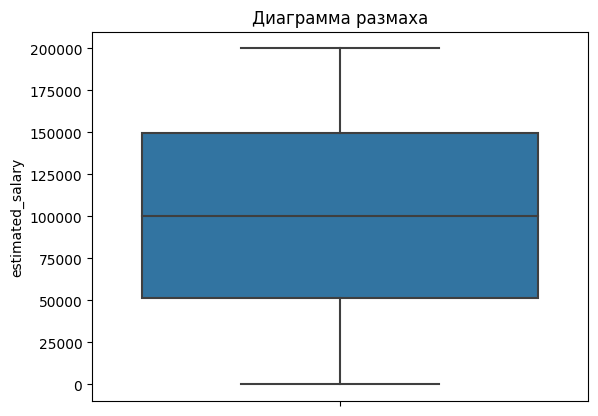

In [38]:
bxplt('estimated_salary')

<div class="alert-success"> 
<b> </b>
Вот всегда бы так, теперь это мой любимый признак) Он идеален)
</div>

<div class="alert-warning"> 
<b> </b>
Целевой признак exited — факт ухода клиента

</div>

0    7646
1    1943
Name: exited, dtype: int64


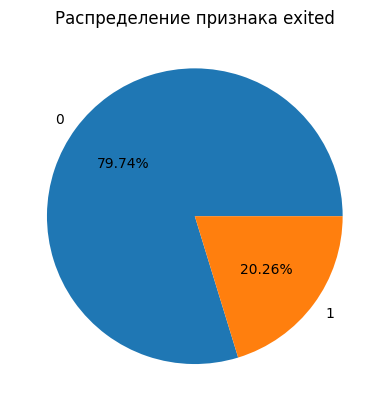

In [39]:
pie('exited')

<div class="alert-success"> 
<b> </b>
Дисбаланс классов на лицо, причем - мажорный класс - '0'(те кто остались) и минорный класс - '1'(те кто ушли)
</div>

<div class="alert-success"> 
<b> </b>
На данном этапе был проведен анализ данных, убраны выбросы и установлено, что в целевом признаке есть дисбаланс классов)
</div>

### 1.4 Корреляционный анализ

<div class="alert-success"> 
<b> </b>
Теперь посмотрим, как будут корреллировать м/у собой признаки и также проверим на мультиколлениарность.
Здесь будет применена phik для анализа и нелинейных зависимостей.

Сразу же очевидно, что факт ухода клиента не будет связан с индексом строки в данных, уникальным идентификатором клиента и фамилией, поэтому при оценки коллениарности данные признаки не учитываются) 
</div>

In [40]:
# создаём список с наименованиями непрерывных признаков
interval_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'num_of_products']

# считаем корреляции на выборке
phik_overview = phik_matrix(data.drop(['row_number', 'customer_id', 'surname'], axis=1), interval_cols=interval_cols)
print(phik_overview.shape)

(11, 11)


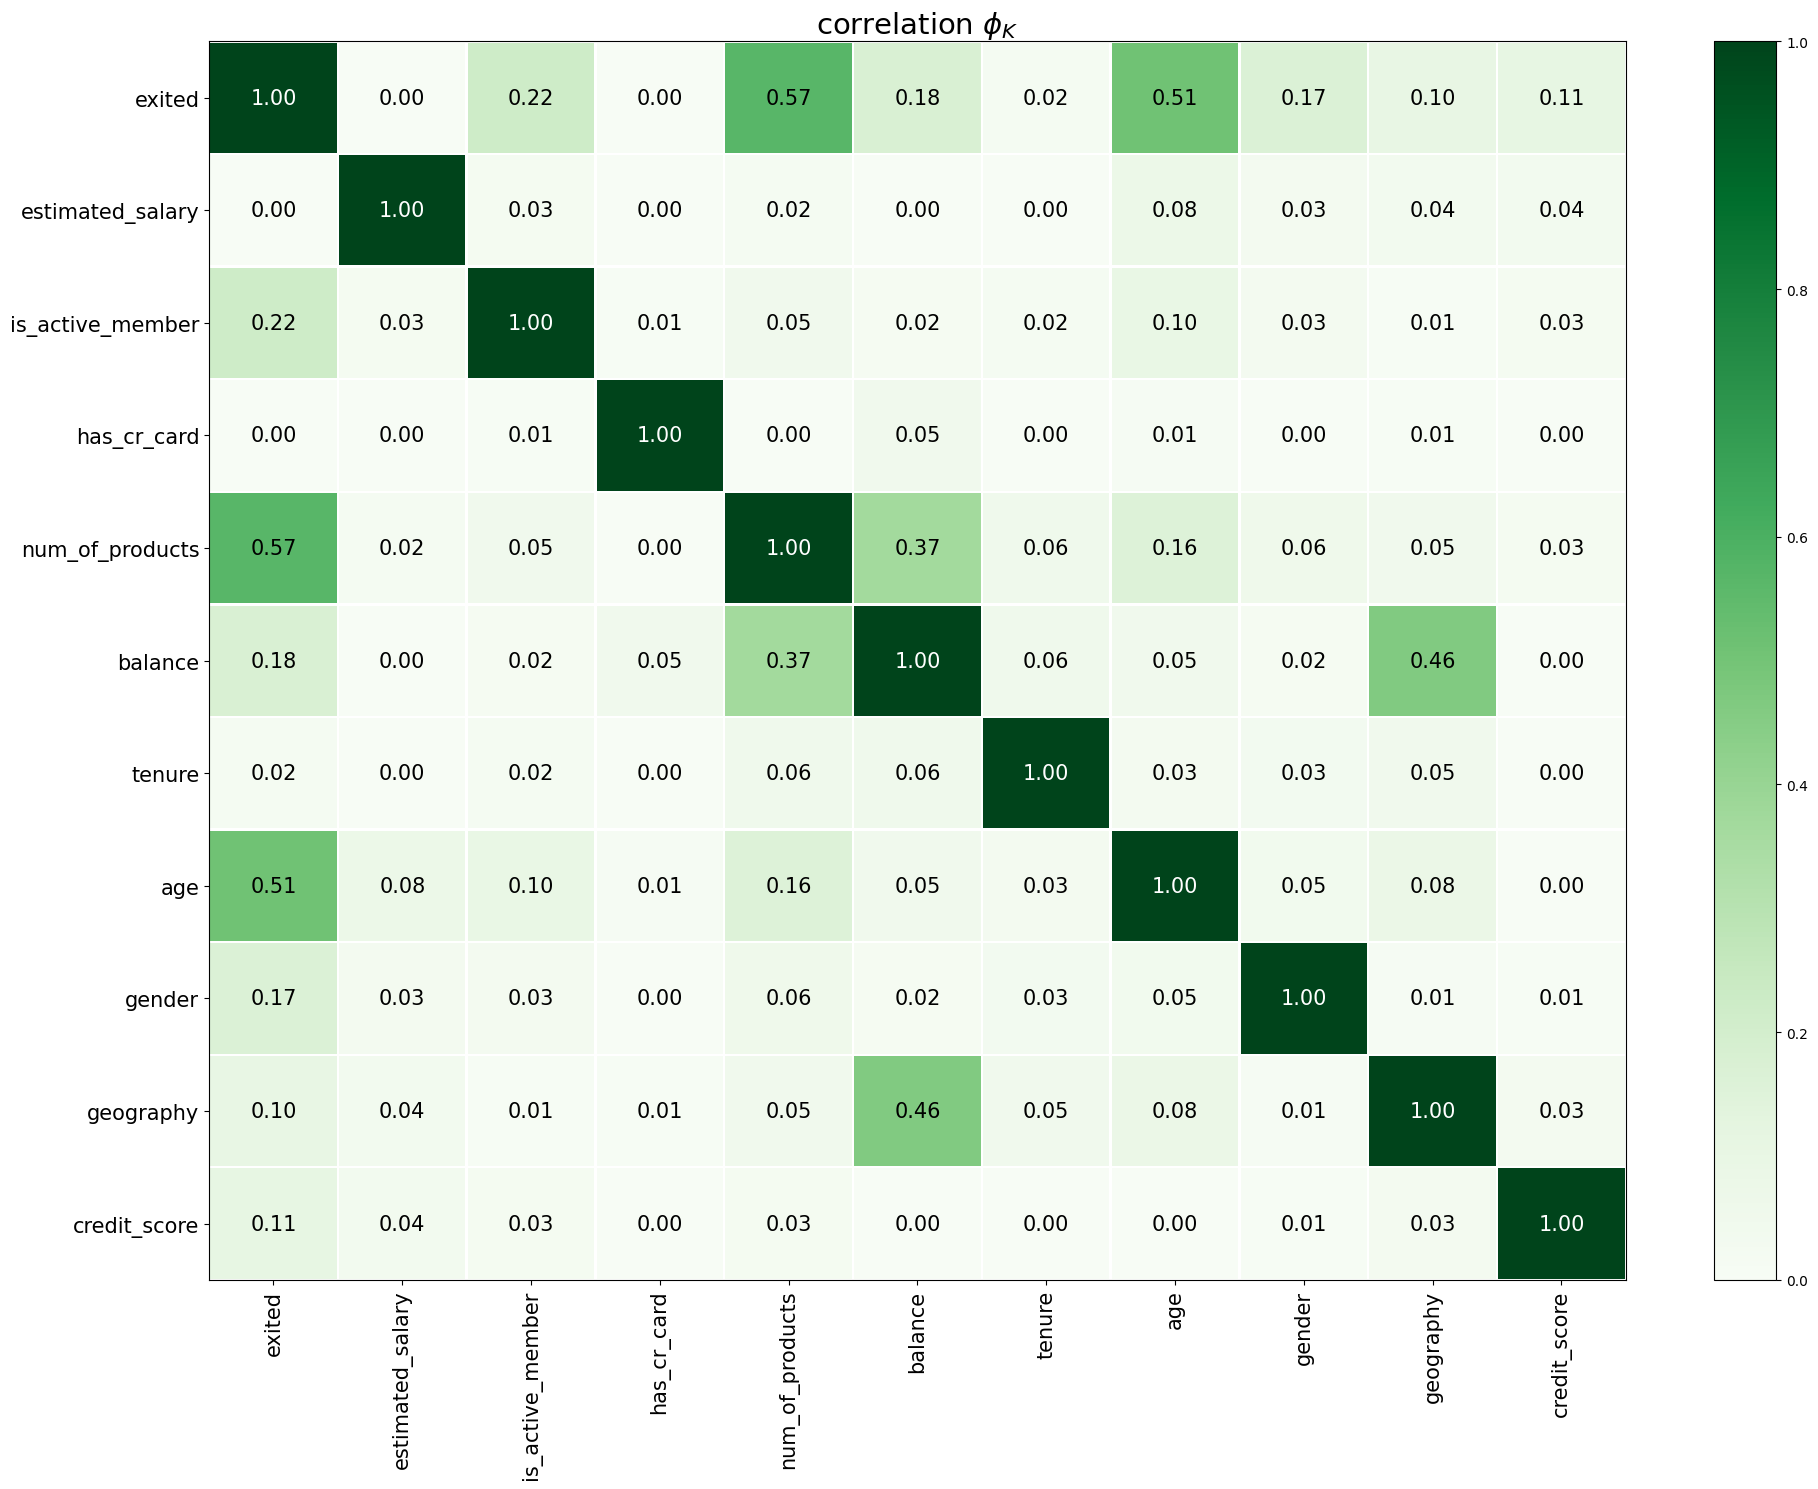

In [41]:
# Функции передаём значения матрицы корреляции phik_overview.values.
# Указываем наименования столбцов x_labels=phik_overview.columns.
# Указываем наименования строк y_labels=phi k_overview.index.
# Указываем цвет градиентной отрисовки vmin=0, vmax=1, color_map='Greens'.
# Добавляем заголовок title=r'correlation $\phi_K$'.
# Увеличиваем размер шрифта fontsize_factor=1.5.
# Увеличиваем размер графика figsize=(20, 15).

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

<div class="alert-success"> 
<b> </b>
Сразу скажу, мультиколлениарности нет и утечки ЦП тоже. Также отмечу, что уход клиента от банка зависит больше всего от таких признаков как возраст, количество продуктов банка, используемых клиентом (активность и баланс тоже вносят свой маленький вклад )

Видно еще что факт прекращения сотруднечества не зависит от наличия кредитной карты и количества лет сколько человек является клиентом банка и предполагаемой зарплаты)

Мы смело можем удалять признаки CustomerId Surname row_number, так как эти признаки не значимые

In [42]:
data = data.drop(['customer_id', 'surname', 'row_number'], axis=1).reset_index(drop=True)

In [43]:
display(data)

,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9584,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9585,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9586,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9587,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


<div class="alert-success"> 
<b> </b>
Отлично, данные предобработаны, исследовательский и статистические анализы проведены и коллинеарность признаков тоже проанализирована) Теперь можно переходить к следующиму этапу --->
</div>

## Шаг 2. Обучение эталонных моделей

<div class="alert-success"> 
<b> </b>
Подготовку признаков выполняем в пайплайне, дополнив пайплайн шага предобработки. При кодировании учитываем особенности признаков и моделей и используем как минимум два кодировщика. Таким образом:

- OneHotEncoder - 'geography', 'gender'
- StandardScaler, MinMaxScaler - 'credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'num_of_products'
</div>

In [44]:
ohe_columns = ['geography', 'gender']
num_columns = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary', 'num_of_products']

In [45]:
X = data.drop('exited', axis=1).reset_index(drop=True)
y = data['exited'].reset_index(drop=True)

In [46]:
# X

In [47]:
# y

<div class="alert-success"> 
<b> </b>
Сплитуем пока что без учета дисбаланса классов
</div>

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

In [49]:
ohe_pipe = Pipeline(
    [

        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output =False)
        )
    ]
) 

In [50]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough',
    force_int_remainder_cols=False  
) 

In [51]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [52]:
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='l1')],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(5, 100),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ['linear', 'rbf'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
    
]
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(force_int_remainder_cols=False,
                                                                remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               ['geography',
                                                                                'gender']),
                                                                              ('num',
                                                                               StandardScaler(),
                                                                               ['credit_score',
                                                                                'age',
                                                                                'tenure',
                                                                                'balance',
                                                                                'es...
                                                               MinMaxScaler(),
                                                               'passthrough']},
                                        {'models': [KNeighborsClassifier()],
                                         'models__n_neighbors': range(5, 100),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']},
                                        {'models': [SVC(probability=True,
                                                        random_state=50)],
                                         'models__kernel': ['linear', 'rbf'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               'passthrough']}],
                   random_state=50, scoring='f1')

In [53]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)
y_test_pred = randomized_search.predict(X_test)
print(f'Метрика ROC-AUC на тестовой выборке (БЕЗ УЧЕТА ДИБАЛАНСА КЛАССОВ): {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['geography', 'gender']),
                                                 ('num', StandardScaler(),
                                                  ['credit_score', 'age',
                                                   'tenure', 'balance',
                                                   'estimated_salary',
  

In [54]:
probabilities = randomized_search.predict_proba(X_test)
probabilities_one = probabilities[:, 1]
print('Площадь ROC-кривой (БЕЗ УЧЕТА ДИБАЛАНСА КЛАССОВ):', roc_auc_score(y_test, probabilities_one))

Площадь ROC-кривой (БЕЗ УЧЕТА ДИБАЛАНСА КЛАССОВ): 0.7379298173115002


In [55]:
f1 = f1_score(y_test, y_test_pred)
print(f'F1-мера на тестовой выборке (БЕЗ УЧЕТА ДИБАЛАНСА КЛАССОВ): {f1:.4f}')

F1-мера на тестовой выборке (БЕЗ УЧЕТА ДИБАЛАНСА КЛАССОВ): 0.4792


- F-мера — это метрика качества классификации, которая агрегирует значения precision и recall. 
    
- F1 — это частный случай F-меры, который показывает среднее гармоническое между precision и recall. Её нужно использовать, когда нам важны результаты обеих исходных метрик.

- ROC-кривая — это график, который отображает динамику качества классификации при разных порогах. Он показывает зависимость между TPR и FPR — промежуточными метриками, которые оценивают число верно классифицированных объектов класса 1 и неверно классифицированных объектов класса 0. Лучшее качество модели — в точке перелома кривой.

- ROC-AUC — это площадь под ROC-кривой. Она оценивает качество решений модели в наиболее общем виде, учитывая все возможные пороговые значения. Поэтому она не зависит от того, какой порог вы выберете, это самая общая оценка итогов работы модели.

<div class="alert-success"> 
<b> </b>
    
Итак результаты обучения (DecisionTreeClassifier(max_depth=2, max_features=3, random_state=50)) такие F1-мера 0.4792  - качество работы модели плохое, то есть модель очень часто ошибается при определении положительного класса — либо пропускает его, либо выдает слишком много ложных срабатываний. ROC-AUC 0.67 — показывает, насколько наша модель хорошо различает классы, в нашем случае она довольно таки средне справляется с данной задачей, далее оценка по вероятностям 0.73 - измеряет, насколько хорошо модель ранжирует объекты по вероятности принадлежности к положительному классу. У нас тоже довольно средний результ, т.е если мы возьмём случайный объект из положительного класса и случайный объект из отрицательного, модель с вероятностью 73% поставит положительному объекту более высокую вероятность.
</div>

## Шаг 3. Оптимизация с учетом дисбаланса

<div class="alert-danger"> 
<b>Применяю метод сэмплирования только к тренировочным данным!</b> 

<div class="alert-success"> 
<b> </b>
    
Буду бороться с проблемой дисбаланса классов методом Oversampling, upsampling —  искусственно увеличить количество объектов минорного класса в датасете до количества объектов мажорного класса. Ниже будет просто для визуализации для меня самой чтобы я оценила работу оверсэмплига, а так я его вставлю в пайплайн)
</div>

In [56]:
sampler = RandomOverSampler(random_state=RANDOM_STATE)
X_train_sampled, y_train_sampled = sampler.fit_resample(X_train, y_train)

In [57]:
# X_train_sampled = pd.DataFrame(X_train_sampled, columns=X_train.columns)
# y_train_sampled = pd.Series(y_train_sampled, name='exited')

In [58]:
print(f'Тренировочные выборка до сэмплирования:\n{X_train.value_counts(), y_train.value_counts()}')
print(f'\nТренировочные выборка после сэмплирования:\n{X_train_sampled.value_counts(), y_train_sampled.value_counts()}')

Тренировочные выборка до сэмплирования:
(credit_score  geography  gender  age  tenure  balance    num_of_products  has_cr_card  is_active_member  estimated_salary
350           France     Female  40   0       111098.85  1                1            1                 172321.21           1
693           France     Male    31   2       0.00       2                1            1                 107759.31           1
696           Spain      Female  36   0       0.00       2                1            1                 82298.59            1
                                 30   0       0.00       2                1            1                 9002.80             1
              Germany    Male    42   7       162318.61  1                1            0                 121061.89           1
                                                                                                                            ..
609           France     Male    32   7       118520.41  1                0

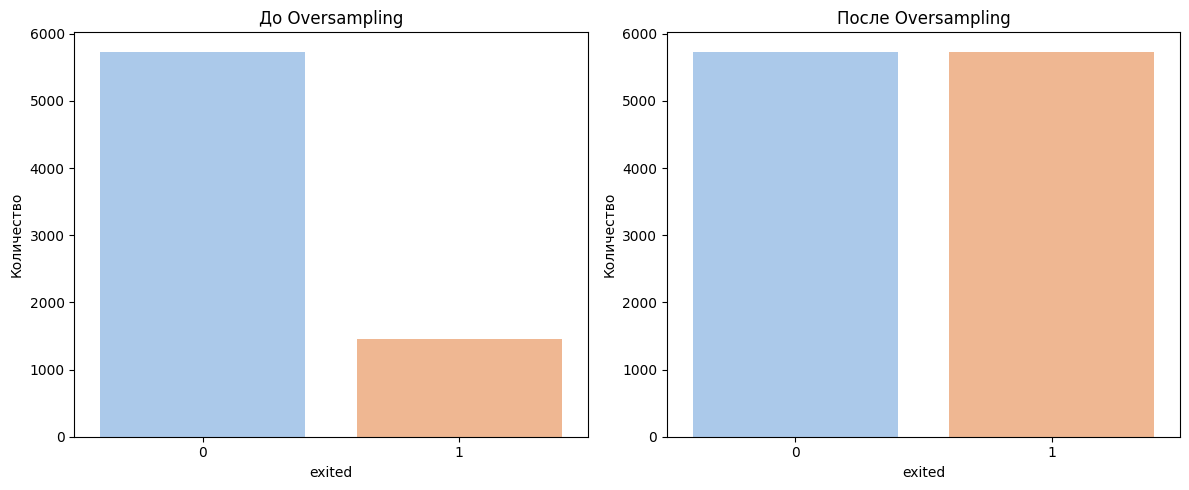

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0], palette='pastel')
axes[0].set_title('До Oversampling')
axes[0].set_xlabel('exited')
axes[0].set_ylabel('Количество')

sns.countplot(x=y_train_sampled, ax=axes[1], palette='pastel')
axes[1].set_title('После Oversampling')
axes[1].set_xlabel('exited')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

<div class="alert-success"> 
<b> </b>
    
Теперь клиентов кто остался и кто ушел ОДИНАКОВОЕ КОЛИЧЕСТВО!!! ---> можно заново обучать)
Я применила все таки базовый оверсэмплинг, потому что У SMOTE и SMOTENC есть недостаток: этот алгоритм просто увеличивает плотность наблюдений в областях пространства, где расположено большинство объектов минорного класса. А если они распределены равномерно и перемешиваются с примерами мажорного класса, то SMOTE и SMOTENC перемешают классы, чем только затруднят классификацию. Не буду рисковать)))
</div>

In [60]:
# cat_indices = [X_train.columns.get_loc(col) for col in ohe_columns]

In [61]:
# smote = SMOTENC(categorical_features=cat_indices, random_state=RANDOM_STATE)

In [62]:
# pipe_final = Pipeline([
#     # ('oversample', smote),
#     ('preprocessor', data_preprocessor),
#     ('model', RandomForestClassifier(random_state=RANDOM_STATE))
# ])

In [63]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('oversample', RandomOverSampler(random_state=RANDOM_STATE)), # вот тут наш сэмплер
    ('model', LGBMClassifier(random_state=RANDOM_STATE))
])

In [64]:
param_grid = [
    {
        'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth': range(5, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    # {
    #     'model': [RandomForestClassifier(random_state=RANDOM_STATE)],
    #     'model__n_estimators': range(49, 55),
    #     'model__max_depth': range(15, 20),
    #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    # # }
    # {
    #     'model': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')],
    #     'model__C': [0.1, 0.5, 1, 5, 10],
    #     'model__penalty': ['l1', 'l2'],
    #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    # }
    # {
    #     'model': [XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss')],
    #     'model__n_estimators': [50, 100, 150],
    #     'model__max_depth': [3, 5, 7],
    #     'model__scale_pos_weight': [1, 5, 10],  # можно настроить под дисбаланс
    #     'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    # }
    {
        'model': [LGBMClassifier(random_state=RANDOM_STATE)],
        'model__n_estimators': [30, 40, 50],
        'model__max_depth': [5, 10, 15, 20],
        # 'model__scale_pos_weight': [1, 2, 3, 4, 5],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# grid_search.fit(X_train_sampled, y_train_sampled)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 66 candidates, totalling 330 fits
[LightGBM] [Info] Number of positive: 5734, number of negative: 5734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 832
[LightGBM] [Info] Number of data points in the train set: 11468, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['geography',
                                                                          'gender']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['credit_score',
                                                                          'age',
                                                                          'tenure',
                                                                          'balance',
                                                                          'estimate...
             param_grid=[{'model': [DecisionTreeClassifier(random_state=50)],
                          'model__max_depth': range(5, 15),
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']},
                         {'model': [LGBMClassifier(random_state=50)],
                          'model__max_depth': [5, 10, 15, 20],
                          'model__n_estimators': [30, 40, 50],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']}],
             scoring='f1', verbose=1)

In [65]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_search.best_score_)
y_test_pred = grid_search.predict(X_test)
print(f'Метрика ROC-AUC на тестовой выборке (С ПРИМЕНЕНИЕМ OVERSAMPLING): {roc_auc_score(y_test, y_test_pred)}')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['geography', 'gender']),
                                                 ('num', MinMaxScaler(),
                                                  ['credit_score', 'age',
                                                   'tenure', 'balance',
                                                   'estimated_salary',
    

C:\Users\admin\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<div class="alert-success"> 
<b> </b>
ИТАК, были перебраны ДВА АЛГОРИТМА С РАЗНЫМИ ГИПЕРПАРАМЕТРАМИ и ЗАФИКСИРОВАНА модель LGBMClassifier(max_depth=15, n_estimators=40, random_state=50) - подобранная лучшая модель (F1-мера = 0.612671326355876), но честно я перепробовала очень много методов и разные модели и добавляла в них class_weight='balance' и разные методы сэмплирования, хотела добиться f1-меры получше, я буду очень признательно если в обратной связи вы дадите комментарий что мне нужно сделать)) Заранее благодарю))
</div>

In [66]:
best_model_after_oversampling = grid_search.best_estimator_

## Шаг 4. Итоговое тестирование и сравнение

<div class="alert-success"> 
<b> </b>
Оценим зафиксированную модель на тестовой выборки, посчитаем для нее roc_auc и вероятностный roc_auc, также построим график roc кривой и сравним F1-меру с ROC AUC, рассмотрим взаимосвязь и практическую значимость)

</div>

In [67]:
probabilities = grid_search.predict_proba(X_test)
probabilities_one = probabilities[:, 1]
print('Площадь ROC-кривой (С ПРИМЕНЕНИЕМ OVERSAMPLING):', roc_auc_score(y_test, probabilities_one))

Площадь ROC-кривой (С ПРИМЕНЕНИЕМ OVERSAMPLING): 0.8728923455068271


C:\Users\admin\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [68]:
f1 = f1_score(y_test, y_test_pred)
print(f'F1-мера на тестовой выборке (С ПРИМЕНЕНИЕМ OVERSAMPLING): {f1:.4f}')

F1-мера на тестовой выборке (С ПРИМЕНЕНИЕМ OVERSAMPLING): 0.6208


<div class="alert-success"> 
<b> </b>
Главное условие выполнено (Основное требование — добиться F1-меры не ниже 0.59 на тестовом наборе.)
</div>

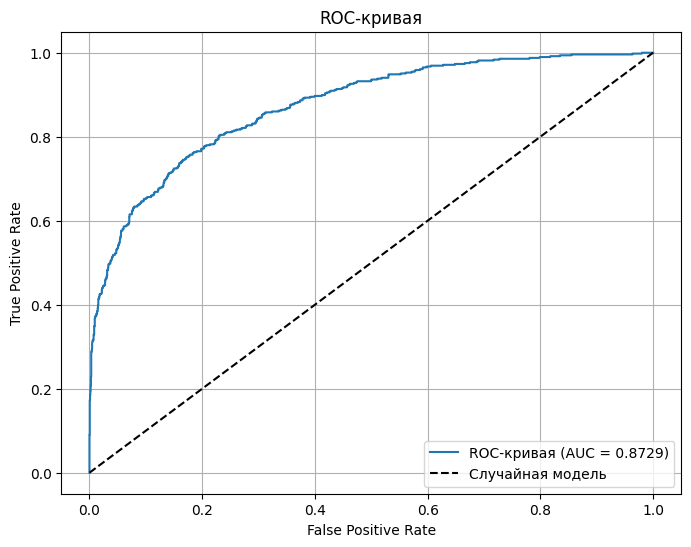

In [69]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities_one)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {roc_auc_score(y_test, probabilities_one):.4f})')
plt.plot([0,1], [0,1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

<div class="alert-success"> 
<b> </b>
Ну тут видно, что кривая находится далеко от диагонали, это хорошо, потому что если бы было наоборот, то это значит, что модель почти не умела бы различать классы) Также по ее изгибу видно, что модель хорошо различает классы при разных трешхолдах)
</div>

<div class="alert-success"> 
<b> </b>
Итак, в конечном итоге мы получили 

- F1-мера: 0.6208

- ROC AUC: 0.8729

Это значит, что в общем случае модель хорошо справляется с задачей классификации, ОДНАКО БЛИН f1 мера меня доканала честно, ее значение говорит нам, что модель всё ещё делает слишком много FP или FN при заданном пороге, честно я думаю что все это из за Oversampling, так как это нечто... помогает модели лучше различать миноритарный класс, увеличивая recall, но из за этого страдает точность поэтому эта дибилка F1 не растёт так сильно.

Вот такие пироги) Про взаимосвязь, я думаю, что при большом ROC AUC все таки можно получить высокий F1,
но только если правильно подобрать порог классификации. 
</div>

In [70]:
precision, recall, thresholds = precision_recall_curve(y_test, probabilities_one)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]
best_f1 = f1[best_idx]

Лучший вариант порога: 0.646
Макс знач меры f1: 0.6512


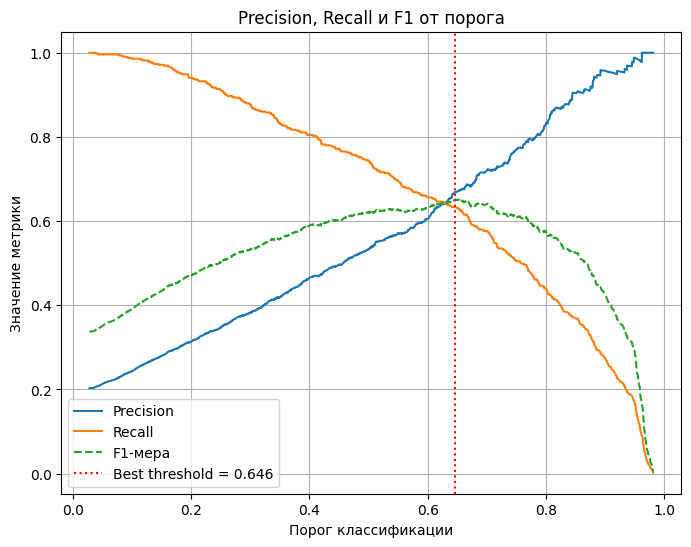

In [71]:
print(f"Лучший вариант порога: {best_threshold:.3f}")
print(f"Макс знач меры f1: {best_f1:.4f}")

plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1[:-1], label="F1-мера", linestyle="--")
plt.axvline(x=best_threshold, color='red', linestyle=':', label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel("Порог классификации")
plt.ylabel("Значение метрики")
plt.title("Precision, Recall и F1 от порога")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert-success"> 
<b> </b>
Ну хоть что то, получилось подобрать порог при котором модель выдает нам f1 меру = 0.6512
</div>

<div class="alert-success"> 
<b> </b>
Рекомендации по использованию модели в бизнес-процессах: 

Ну очевидно что, модель можно использовать для того, чтобы выявлять клиентов кто потенциально может уйти от банка и на основе этого можно уделять особое внимание таким клиентам, а именно, предлагать клиенту какие нибудь новые условия или акции, также возможно предложить такому клиенту какие нибудь новые продукты от банка, что поможет удержать клиентов). Однако, модель дает увидеть вероятность того, что клиент может уйти, но не дает 100% гарантию, поэтому к ней надо относится как к "помощнику", и оставлять решение на сотруднике банка.
</div>

## Шаг 4. Итоговые выводы

- Итак, в данной работе мы выявили "портрет" среднестатистического клиента нашего банка - кредитный рейтинг у таких обычно около 650, живет во франции, мужчина, возрастом около 38, является клиентом на протяжении 4-4.5 лет со счетом 70-97тыс, пользуется кредиткой и одним двумя продуктами от банка)

- (рекомендации на основе полученных показателей) Все это поможет нам лучше понимать клиентов банка и почему они уходят, предлагать больше новых продуктов от банка, если он из франции, то делать специальные предложение жителям франции, также статистический анализ показал что довольно таки много клиентов только начинают пользоваться услугами банка или же наоборот уже более 10 лет с ними, для людей этих категорий можно дать какие нибудь приятные бонусы или сделать им специальное предложение. Еще среди клиентов много кто пользуется кредитной картой, это тоже может сыграть на руку банку и можно к примеру таким людям предлагать особые условия и тд.

- Также при исследовательском и статистическом анализах был выявлен дисбаланс классов ушедших клиентов оказалось в разы меньше чем оставшихся

- Также в данной лабораторной работе были обучены модели и результат работы модели после утсранения дисбаланса классов с помощью метода oversampling оказался лучше, чем без него.

- Также нам удалось спрогнозировать вероятность прекращения сотрудничества клиента с банком с помощью лучшей модели - LGBMClassifier(max_depth=15, n_estimators=40, random_state=50) и оценить точность данного прогноза по двум метрикам (F1-мера: 0.6208, ROC AUC: 0.8729), главное требование лабораторной работы было учтено и выполнено. 

- Также после анализа значений метрик был подобран оптимальный порог для классификации = 0.646 и с его помощью я добилась f1 = 0.6512.

Работа выполнена Гареевой Д.Р (507540), j4150